# 프로젝트 2 — Weekend 2: 리랭킹과 답변 품질 평가

**프로젝트**: 검색형 RAG 기반 금융 상품(ETF) 추천 시스템

**이번 주 목표**:
1. LLM 리랭킹으로 검색 결과 품질 향상
2. BLEU, ROUGE, BERTScore 자동 평가 지표 구현
3. LLM-as-Judge 평가 파이프라인 구축
4. Criteria 기반 다차원 평가와 품질 게이트 구현

---
## 환경 설정

In [7]:
# 환경 설정 및 라이브러리 설치
!pip install -q openai langchain langchain-openai langchain-community faiss-cpu \
    rank_bm25 pandas numpy matplotlib gradio python-dotenv tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [8]:
# 환경 설정
import os, json, time, re, math
import numpy as np
import pandas as pd
from collections import Counter
from datetime import datetime

from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# from dotenv import load_dotenv
# load_dotenv()

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.vectorstores import FAISS

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
MODEL = "gpt-4o-mini"

print("✅ 환경 설정 완료")

✅ 환경 설정 완료


## 데이터 준비

In [9]:
# ETF 샘플 데이터
SAMPLE_ETF_DATA = [
    {"ticker": "KODEX200", "name": "KODEX 200", "category": "국내주식",
     "description": "KOSPI 200 지수를 추종하는 국내 대표 ETF. 삼성전자, SK하이닉스 등 대형주 중심.",
     "expense_ratio": 0.15, "aum_billion": 58000, "risk_level": "중간"},
    {"ticker": "TIGER미국S&P500", "name": "TIGER 미국 S&P500", "category": "해외주식",
     "description": "미국 S&P 500 지수를 추종. 애플, 마이크로소프트 등 미국 대형주 투자.",
     "expense_ratio": 0.07, "aum_billion": 45000, "risk_level": "중간"},
    {"ticker": "KODEX배당가치", "name": "KODEX 배당가치", "category": "배당",
     "description": "고배당 가치주 중심 ETF. 은행, 통신 등 배당 수익률이 높은 종목.",
     "expense_ratio": 0.30, "aum_billion": 8500, "risk_level": "낮음"},
    {"ticker": "TIGER반도체", "name": "TIGER 반도체", "category": "섹터",
     "description": "국내 반도체 산업 ETF. 삼성전자, SK하이닉스 등 반도체 관련주.",
     "expense_ratio": 0.40, "aum_billion": 12000, "risk_level": "높음"},
    {"ticker": "KODEX국고채3년", "name": "KODEX 국고채 3년", "category": "채권",
     "description": "한국 3년 만기 국고채에 투자하는 안정형 ETF.",
     "expense_ratio": 0.05, "aum_billion": 25000, "risk_level": "매우낮음"},
    {"ticker": "TIGER차이나CSI300", "name": "TIGER 차이나 CSI300", "category": "해외주식",
     "description": "중국 CSI 300 지수 추종. 상해/심천 대형주 투자.",
     "expense_ratio": 0.25, "aum_billion": 3500, "risk_level": "높음"},
    {"ticker": "KODEX골드선물", "name": "KODEX 골드선물(H)", "category": "원자재",
     "description": "금 선물 가격을 추종하는 원자재 ETF. 인플레이션 헤지 수단.",
     "expense_ratio": 0.68, "aum_billion": 5200, "risk_level": "중간"},
    {"ticker": "TIGER리츠부동산", "name": "TIGER 리츠부동산인프라", "category": "부동산",
     "description": "국내 리츠 및 부동산 인프라 기업에 투자. 배당 수익 추구.",
     "expense_ratio": 0.29, "aum_billion": 4100, "risk_level": "중간"},
    {"ticker": "KODEX2차전지", "name": "KODEX 2차전지산업", "category": "섹터",
     "description": "2차전지 관련 기업에 투자. LG에너지솔루션, 삼성SDI 등.",
     "expense_ratio": 0.45, "aum_billion": 18000, "risk_level": "높음"},
    {"ticker": "TIGER단기통안채", "name": "TIGER 단기통안채", "category": "채권",
     "description": "초단기 통안채에 투자. 파킹 용도로 활용되는 안전 자산.",
     "expense_ratio": 0.03, "aum_billion": 32000, "risk_level": "매우낮음"},
]

EVAL_QUERIES = [
    {"query": "안정적인 배당 ETF를 추천해주세요",
     "reference": "KODEX 배당가치 ETF를 추천합니다. 은행, 통신 등 고배당 가치주에 투자하며 리스크가 낮습니다. 수수료는 0.30%입니다.",
     "relevant_etfs": ["KODEX배당가치", "TIGER리츠부동산"]},
    {"query": "미국 주식에 투자하고 싶어요",
     "reference": "TIGER 미국 S&P500 ETF를 추천합니다. 애플, 마이크로소프트 등 미국 대형주에 투자하며 수수료가 0.07%로 저렴합니다.",
     "relevant_etfs": ["TIGER미국S&P500"]},
    {"query": "원금 손실 위험이 적은 ETF는?",
     "reference": "TIGER 단기통안채 ETF를 추천합니다. 초단기 통안채에 투자하여 원금 손실 위험이 매우 낮으며 수수료도 0.03%입니다.",
     "relevant_etfs": ["KODEX국고채3년", "TIGER단기통안채"]},
    {"query": "반도체 섹터에 투자하려면?",
     "reference": "TIGER 반도체 ETF를 추천합니다. 삼성전자, SK하이닉스 등 반도체 관련주에 집중 투자합니다. 리스크가 높으니 주의하세요.",
     "relevant_etfs": ["TIGER반도체"]},
    {"query": "인플레이션 헤지 방법이 있을까요?",
     "reference": "KODEX 골드선물(H) ETF를 고려해보세요. 금 선물 가격을 추종하여 인플레이션 헤지 수단으로 활용됩니다.",
     "relevant_etfs": ["KODEX골드선물"]},
    {"query": "중국 시장에 투자하는 ETF는?",
     "reference": "TIGER 차이나 CSI300 ETF가 있습니다. 상해/심천 대형주에 투자하지만 리스크가 높으니 신중하게 투자하세요.",
     "relevant_etfs": ["TIGER차이나CSI300"]},
]

print(f"✅ ETF {len(SAMPLE_ETF_DATA)}개, 평가 질의 {len(EVAL_QUERIES)}개")

✅ ETF 10개, 평가 질의 6개


## Weekend 1 복원: 벡터 스토어 + 하이브리드 검색

In [10]:
# Weekend 1 체크포인트 복원
import pickle
#from langchain.schema import Document
from langchain_core.documents import Document
from rank_bm25 import BM25Okapi

# 코드 기존 경로
# vs_path = "project2_data/vectorstore/faiss_baseline"

# ⭐ 경로 변경: Google Drive 경로
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/project2_data"
vs_path   = f"{BASE_DIR}/vectorstore/faiss_baseline"
json_path = f"{BASE_DIR}/raw/etf_documents.json"

os.makedirs(f"{BASE_DIR}/vectorstore", exist_ok=True)
os.makedirs(f"{BASE_DIR}/raw", exist_ok=True)

# vectorstore 및 BM25용 json 파일 구축 시:
  # 최초 구축(Creation) 단계"에서는 동일한 소스(SAMPLE_ETF_DATA) 사용

if os.path.exists(vs_path):
    vs = FAISS.load_local(vs_path, embeddings, allow_dangerous_deserialization=True)
    #with open("project2_data/raw/etf_documents.json") as f: # --------- ⭐ 기존 경로
    with open(json_path) as f:  # ⭐ 추가: json_path 변수 사용
        etf_docs = json.load(f)
    print(f"✅ 체크포인트 복원: {vs.index.ntotal}개 문서")
else:
    # 문서 객체를 각각 두 개로 나눠서 이용
    docs = [] # 👈 1. 벡터스토어(vs)에 넣을 포장지(Document 객체) 리스트
    etf_docs = {}  # 👈 2. JSON 파일로 저장해서 BM25가 쓸 원본 텍스트 딕셔너리
    for etf in SAMPLE_ETF_DATA:
        content = f"{etf['name']} ({etf['ticker']}): {etf['description']} 카테고리: {etf['category']}, 수수료: {etf['expense_ratio']}%, 리스크: {etf['risk_level']}"
        docs.append(Document(page_content=content, metadata={"ticker": etf["ticker"]}))
        etf_docs[etf["ticker"]] = {"name": etf["name"], "content": content, "category": etf["category"]}
    vs = FAISS.from_documents(docs, embeddings)
    vs.save_local(vs_path)                                           # ⭐ 추가
    with open(json_path, "w", encoding="utf-8") as f:               # ⭐ 추가
      json.dump(etf_docs, f, ensure_ascii=False, indent=2)
    print(f"✅ 새로 구축: {vs.index.ntotal}개 문서")

all_contents = [etf_docs[k]["content"] for k in etf_docs]
all_keys = list(etf_docs.keys())
bm25 = BM25Okapi([doc.split() for doc in all_contents]) # BM25Okapi는 파이썬의 외부 라이브러리

def hybrid_search(query, k=5, alpha=0.5):
    """BM25 + 벡터 하이브리드 검색 (RRF)"""
    vec_results = vs.similarity_search_with_score(query, k=k)
    vec_ids = [(doc.metadata.get("ticker", ""), score) for doc, score in vec_results]
    bm25_scores = bm25.get_scores(query.split())
    bm25_ranked = sorted(enumerate(bm25_scores), key=lambda x: x[1], reverse=True)[:k]
    bm25_ids = [(all_keys[idx], score) for idx, score in bm25_ranked]
    rrf_scores = {}
    for rank, (doc_id, _) in enumerate(vec_ids):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + alpha / (rank + 60)
    for rank, (doc_id, _) in enumerate(bm25_ids):
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + (1 - alpha) / (rank + 60)
    sorted_results = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)[:k]
    return [(doc_id, rrf_scores[doc_id], etf_docs.get(doc_id, {}).get("content", "")) for doc_id, _ in sorted_results]

print("✅ hybrid_search 준비 완료")

✅ 새로 구축: 10개 문서
✅ hybrid_search 준비 완료


---
### 실습 1: Hit Rate 계산

`hybrid_search`의 Hit Rate@K를 계산하세요.

- `hit_rate(eval_data, search_fn, k)` 함수 구현
- `EVAL_QUERIES`의 `relevant_etfs` 중 하나라도 검색 결과에 있으면 hit
- k=3, k=5에서 각각 측정

In [12]:
query = "안정적인 배당 ETF를 추천해주세요"
result = vs.similarity_search_with_score(query, k=3)
result


[(Document(id='45c63a95-dbef-4052-896d-33474bb6fb02', metadata={'ticker': 'KODEX배당가치'}, page_content='KODEX 배당가치 (KODEX배당가치): 고배당 가치주 중심 ETF. 은행, 통신 등 배당 수익률이 높은 종목. 카테고리: 배당, 수수료: 0.3%, 리스크: 낮음'),
  np.float32(1.0504177)),
 (Document(id='aea90c89-10a9-455a-afdc-6e8c2e93f38c', metadata={'ticker': 'KODEX국고채3년'}, page_content='KODEX 국고채 3년 (KODEX국고채3년): 한국 3년 만기 국고채에 투자하는 안정형 ETF. 카테고리: 채권, 수수료: 0.05%, 리스크: 매우낮음'),
  np.float32(1.0824286)),
 (Document(id='3c41bc76-d433-4dc0-b6fc-8ab6d8f8fefd', metadata={'ticker': 'KODEX200'}, page_content='KODEX 200 (KODEX200): KOSPI 200 지수를 추종하는 국내 대표 ETF. 삼성전자, SK하이닉스 등 대형주 중심. 카테고리: 국내주식, 수수료: 0.15%, 리스크: 중간'),
  np.float32(1.2006769))]

In [15]:
result[0][0]

Document(id='45c63a95-dbef-4052-896d-33474bb6fb02', metadata={'ticker': 'KODEX배당가치'}, page_content='KODEX 배당가치 (KODEX배당가치): 고배당 가치주 중심 ETF. 은행, 통신 등 배당 수익률이 높은 종목. 카테고리: 배당, 수수료: 0.3%, 리스크: 낮음')

In [14]:
hs_result = hybrid_search(query, k=3)
hs_result, hs_result[0]

([('KODEX배당가치',
   0.016530054644808743,
   'KODEX 배당가치 (KODEX배당가치): 고배당 가치주 중심 ETF. 은행, 통신 등 배당 수익률이 높은 종목. 카테고리: 배당, 수수료: 0.3%, 리스크: 낮음'),
  ('KODEX200',
   0.016129032258064516,
   'KODEX 200 (KODEX200): KOSPI 200 지수를 추종하는 국내 대표 ETF. 삼성전자, SK하이닉스 등 대형주 중심. 카테고리: 국내주식, 수수료: 0.15%, 리스크: 중간'),
  ('TIGER리츠부동산',
   0.008333333333333333,
   'TIGER 리츠부동산인프라 (TIGER리츠부동산): 국내 리츠 및 부동산 인프라 기업에 투자. 배당 수익 추구. 카테고리: 부동산, 수수료: 0.29%, 리스크: 중간')],
 ('KODEX배당가치',
  0.016530054644808743,
  'KODEX 배당가치 (KODEX배당가치): 고배당 가치주 중심 ETF. 은행, 통신 등 배당 수익률이 높은 종목. 카테고리: 배당, 수수료: 0.3%, 리스크: 낮음'))

In [16]:
# 실습 1
# hybrid_search 함수 및 EVAL_QUERY 이용한 테스트, Hit Rate 계산

"""
EVAL_QUERIES = [
    {"query": "안정적인 배당 ETF를 추천해주세요",
     "reference": "KODEX 배당가치 ETF를 추천합니다. 은행, 통신 등 고배당 가치주에 투자하며 리스크가 낮습니다. 수수료는 0.30%입니다.",
     "relevant_etfs": ["KODEX배당가치", "TIGER리츠부동산"]},

     ....
"""
# hit-rate는 검색 결과로 반환한게 맞으면 1, 아니면 0의 스코어링을 하는 것.
# eval_data는 EVAL_QUERIES 이고, hit-rate 대상은 relevant
  # hit_rate 함수에서 search_fn은 그냥 hybrid_search 함수를 인자로 주면 되고,
    # 해당 함수는 query와 k만 주면 관련 results를 반환
    # 반환된 result는 {티커, 스코어, 카테고리}로 구성

def hit_rate(eval_data, search_fn, k=5):
    hits = 0
    for item in eval_data:
        results = search_fn(item["query"], k=k)

        found_ids = [r[0] for r in results] # r[0]은 티커명, ('KODEX배당가치', 'KODEX200' 등) r[1]은 score

        # ⭐ [추가] 디버깅용
        relevant_etfs = item.get("relevant_etfs", [])
        print(f"""
        Found: {found_ids} | \n\
        Relevant: {relevant_etfs} | \n\
        Matched: {list(set(found_ids) & set(relevant_etfs))}""")

        # 만약 found_ids가 eval_data의 "relevant_etfs"와 하나라도 맞으면 1, 아니면 0
        if set(found_ids) & set(item.get("relevant_etfs", [])):
        #if found_ids in item.get("relevant_etfs"):
          hits += 1
        else:
          pass

    return hits / len(eval_data) # item 항목별 1(맞음) or 0(틀림)의 평균값 반환

for k in [3, 5]:
    print("\n")
    hr = hit_rate(EVAL_QUERIES, hybrid_search, k=k)
    print(f"\n====== Hit Rate@{k}: {hr:.3f} ======")




        Found: ['KODEX배당가치', 'KODEX200', 'TIGER리츠부동산'] | 
        Relevant: ['KODEX배당가치', 'TIGER리츠부동산'] | 
        Matched: ['TIGER리츠부동산', 'KODEX배당가치']

        Found: ['TIGER미국S&P500', 'TIGER단기통안채', 'KODEX200'] | 
        Relevant: ['TIGER미국S&P500'] | 
        Matched: ['TIGER미국S&P500']

        Found: ['KODEX배당가치', 'KODEX200', 'KODEX국고채3년'] | 
        Relevant: ['KODEX국고채3년', 'TIGER단기통안채'] | 
        Matched: ['KODEX국고채3년']

        Found: ['TIGER반도체', 'KODEX2차전지', 'KODEX200'] | 
        Relevant: ['TIGER반도체'] | 
        Matched: ['TIGER반도체']

        Found: ['KODEX골드선물', 'TIGER단기통안채', 'TIGER리츠부동산'] | 
        Relevant: ['KODEX골드선물'] | 
        Matched: ['KODEX골드선물']

        Found: ['KODEX국고채3년', 'TIGER미국S&P500', 'TIGER차이나CSI300'] | 
        Relevant: ['TIGER차이나CSI300'] | 
        Matched: ['TIGER차이나CSI300']

====== Hit Rate@3: 1.000 ======



        Found: ['KODEX배당가치', 'KODEX200', 'TIGER반도체', 'TIGER리츠부동산', 'KODEX국고채3년'] | 
        Relevant: ['KODEX배당가치', 'TIGER리츠부동산'] | 
     

---
### RAG 답변 생성 파이프라인

In [17]:
# RAG 답변 생성
def ask_etf(query, k=3, verbose=False):
    results = hybrid_search(query, k=k) # 반환값은 item별 {티커, 스코어, 카테고리}
    context = "\n\n".join([f"[{doc_id}] {content}" for doc_id, score, content in results]) # 하나로 합침
    _llm = ChatOpenAI(model=MODEL, temperature=0)
    answer = _llm.invoke([
        SystemMessage(content="ETF 전문가입니다. 검색된 문서만을 근거로 답변하세요. 추측하지 마세요."),
        HumanMessage(content=f"참고 문서:\n{context}\n\n질문: {query}")
    ]).content
    if verbose:
        print(f"Q: {query}\nA: {answer[:200]}...")
    return answer

# 전체 답변 생성 (이후 실습에서 사용)
answers = {}
for item in EVAL_QUERIES:
    answers[item["query"]] = ask_etf(item["query"])
print(f"✅ {len(answers)}개 답변 생성 완료")

✅ 6개 답변 생성 완료


In [55]:
answers.keys()

dict_keys(['안정적인 배당 ETF를 추천해주세요', '미국 주식에 투자하고 싶어요', '원금 손실 위험이 적은 ETF는?', '반도체 섹터에 투자하려면?', '인플레이션 헤지 방법이 있을까요?', '중국 시장에 투자하는 ETF는?'])

In [56]:
answers.get('안정적인 배당 ETF를 추천해주세요')

'안정적인 배당 ETF로는 **KODEX 배당가치**를 추천합니다. 이 ETF는 고배당 가치주 중심으로 구성되어 있으며, 은행과 통신 등 배당 수익률이 높은 종목에 투자합니다. 수수료는 0.3%로 낮고, 리스크도 낮은 편입니다. \n\n또한, **TIGER 리츠부동산인프라**도 고려할 수 있습니다. 이 ETF는 국내 리츠 및 부동산 인프라 기업에 투자하여 배당 수익을 추구하며, 수수료는 0.29%로 중간 수준의 리스크를 가지고 있습니다. \n\n이 두 ETF 모두 안정적인 배당 수익을 추구하는 투자자에게 적합합니다.'

### 실습 2: temperature 비교

temperature=0 vs 0.7로 답변을 생성하고 길이, 소요시간을 비교하세요.

- `ask_etf_v2(query, k, temperature, max_tokens)` → `(answer, elapsed)` 반환
- `ChatOpenAI(model=MODEL, temperature=..., max_tokens=...).invoke()` 사용

In [35]:
# 실습 2
# 답변 생성, temperature=0 및 7

import time

""" hybrid_search() 결과
('KODEX배당가치',
  0.016530054644808743,
  'KODEX 배당가치 (KODEX배당가치): 고배당 가치주 중심 ETF. 은행, 통신 등 배당 수익률이 높은 종목. 카테고리: 배당, 수수료: 0.3%, 리스크: 낮음'),
"""

def ask_etf_v2(query, k=3, temperature=0, max_tokens=500):

    results = hybrid_search(query, k=k)
    context = "\n".join([f"[{did}] {c}" for did, _, c in results]) # 티커, _, context(+카테고리) 순으로 k=3개가 반환되는데
                                                                   # 반환되는 context(즉, did 및 c) 여러개를 join 함수로 모두 합침
    start = time.time()

    prompt = f"""당신은 ETF 전문가입니다. 아래 제공된 [정보]를 이용하여 사용자의 [질문]에 답변하세요.

    [정보]
    {context}

    [질문]
    {query}

    답변:"""

    llm = ChatOpenAI(model=MODEL, temperature=temperature, max_tokens=max_tokens)
    answer = llm.invoke(query).content
    print(f"answer: {answer}")

    end = time.time()
    elapsed = end - start

    return answer, elapsed

q = "안정적인 배당 ETF를 추천해주세요"
a0, t0 = ask_etf_v2(q, temperature=0)
print("="*20)
a7, t7 = ask_etf_v2(q, temperature=0.7)
print("="*20)
print(f"temp=0: {len(a0)}자, {t0:.2f}초")
print(f"temp=0.7: {len(a7)}자, {t7:.2f}초")

answer: 안정적인 배당 ETF를 찾고 계신다면, 다음과 같은 ETF를 고려해볼 수 있습니다. 이들은 일반적으로 안정적인 배당 수익을 제공하는 기업들로 구성되어 있습니다.

1. **Vanguard Dividend Appreciation ETF (VIG)**: 이 ETF는 배당금을 지속적으로 증가시켜온 기업들에 투자합니다. 안정적인 배당 성향을 가진 대형주 중심으로 구성되어 있습니다.

2. **iShares Select Dividend ETF (DVY)**: 이 ETF는 높은 배당 수익률을 가진 미국 기업에 투자하며, 안정적인 배당을 지급하는 기업들로 포트폴리오를 구성합니다.

3. **Schwab U.S. Dividend Equity ETF (SCHD)**: 이 ETF는 배당금 지급 이력이 있는 미국 기업에 투자하며, 안정적인 배당 수익을 추구합니다.

4. **SPDR S&P Dividend ETF (SDY)**: S&P 1500 지수에서 최소 20년 이상 배당금을 증가시킨 기업들로 구성된 ETF입니다. 안정적인 배당 성향을 가진 기업들로 포트폴리오가 구성되어 있습니다.

5. **Invesco S&P 500 High Dividend Low Volatility ETF (SPHD)**: 이 ETF는 S&P 500 지수에서 높은 배당 수익률과 낮은 변동성을 가진 기업들에 투자합니다.

각 ETF의 성과와 배당 수익률은 시장 상황에 따라 달라질 수 있으므로, 투자 결정을 내리기 전에 충분한 조사와 분석을 하는 것이 중요합니다. 또한, 개인의 투자 목표와 리스크 수용 능력에 맞는 ETF를 선택하는 것이 좋습니다.
answer: 안정적인 배당 ETF를 찾고 계신다면, 다음과 같은 ETF를 고려해볼 수 있습니다. 이들 ETF는 일반적으로 안정적인 배당을 지급하는 기업들로 구성되어 있습니다.

1. **Vanguard Dividend Appreciation ETF (VIG)**: 이 ETF는 배당금을 지속적으로 증가시켜 온 기업들에 투자하며, 안정적인 성장을 목표

---
### LLM 리랭킹

In [36]:
# LLM 기반 리랭킹
def llm_rerank(query, documents, top_k=3):
    doc_list = "\n".join([
        f"[{i}] {doc_id}: {content[:150]}"
        for i, (doc_id, score, content) in enumerate(documents)
    ])
    _llm = ChatOpenAI(model=MODEL, temperature=0).bind(
        response_format={"type": "json_object"}
    )
    response = _llm.invoke([
        SystemMessage(content="ETF 검색 결과를 질의 관련성 순으로 재정렬하는 전문가입니다."),
        HumanMessage(content=f"""질문: {query}

검색 결과:
{doc_list}

위 검색 결과를 질문과의 관련성 순으로 정렬하세요.
각 문서에 1-10점 관련성 점수를 부여하세요.
JSON: {{"rankings": [{{"index": 0, "score": 9, "reason": "이유"}}]}}""")
    ])
    try:
        result = json.loads(response.content)
        rankings = result if isinstance(result, list) else result.get("rankings", result.get("results", []))
        rankings.sort(key=lambda x: x.get("score", 0), reverse=True)
        reranked = []
        for r in rankings[:top_k]:
            idx = r["index"]
            if 0 <= idx < len(documents):
                doc_id, _, content = documents[idx]
                reranked.append((doc_id, r["score"], content))
        return reranked
    except Exception as e:
        print(f"⚠️ 리랭킹 실패: {e}")
        return documents[:top_k]

print("✅ llm_rerank 준비 완료")

✅ llm_rerank 준비 완료


### 실습 3: 리랭킹 전후 Hit Rate 비교

리랭킹 적용 전후의 Hit Rate를 비교하세요.

- `hybrid_search(k=7)` → 상위 `k_rerank`개 vs `llm_rerank()` 후 `k_rerank`개
- 쿼리별 결과와 평균 소요시간 출력

In [39]:
# 실습 3
def compare_reranking(eval_data, k_initial=7, k_rerank=3):
    hit_before, hit_after = 0, 0
    total_time = 0

    for item in eval_data:
        initial = hybrid_search(item["query"], k=k_initial) # 우선은 hybrid_search로 query에 대한 후보군을 뽑음
        ids_before = [r[0] for r in initial[:k_rerank]] # 티커(id)들을 리스트로 저장 (before)

        start = time.time()
        reranked = llm_rerank(item["query"], initial, top_k=k_rerank) # 초기 뽑은 후보군들(initial)을 재순위화(rerank)
        total_time += time.time() - start
        ids_after = [r[0] for r in reranked] # 재순위화 이후 티커들 (after)

        # ---- 여기에 코드 작성 ----
        # ids_before, ids_after에서 relevant_etfs 존재 여부 확인

        # hit_rate 계산
         # eval_data의 item에는 'relevant_ids' 라는 키값 존재.
         # 해당 값들과 ids_before의 각 속성의 set()이 매칭되면 1, 아니면 0인데
         # 문제는 ids_before이 eval_data에 5개 들어있는 요소 중 하나에 대해서 관련 문서 k=7 개를 뽑아온 것인지..?

        # 정답 티커 리스트를 set으로 변환
        target_set = set(item["relevant_etfs"])

        # ids_before와 정답 집합의 교집합이 있는지 확인 (처음 뽑은 7개의 관련문서)
        if set(ids_before) & target_set:
          hit_before += 1

        # ids_after와 정답 집합의 교집합이 있는지 확인 (rerank된 3개의 문서)
        if set(ids_after) & target_set:
          hit_after += 1

    n = len(eval_data)
    print(f"\nHit Rate@{k_rerank}: {hit_before/n:.3f} → {hit_after/n:.3f}")
    print(f"평균 리랭킹 시간: {total_time/n:.2f}초")

compare_reranking(EVAL_QUERIES)


Hit Rate@3: 1.000 → 1.000
평균 리랭킹 시간: 5.49초


---
### 스코어 필터링 + 통합 파이프라인

In [40]:
# 스코어 필터링
def score_filter(results, method="dynamic"): # 어떤 문서를 버릴 것인지에 대한 함수
    if not results:
        return results
    scores = [r[1] for r in results]
    if method == "fixed": #  고정 임계값 방식, score가 특정 값 미만이면 버림.
        threshold = 5.0
    elif method == "dynamic": # 평균과 표준편차 활용
        threshold = np.mean(scores) - np.std(scores)
    elif method == "gap": # 문서들 중에서 점수가 갑자기 크게 차이나는(Gap) 문서를 탐지.
        gaps = [scores[i] - scores[i+1] for i in range(len(scores)-1)]
        threshold = scores[np.argmax(gaps) + 1] + 0.01 if gaps else 0
    else:
        threshold = 0
    filtered = [(d, s, c) for d, s, c in results if s >= threshold]
    return filtered if filtered else results[:1]

def rag_pipeline(query, k_search=7, k_rerank=5, filter_method="dynamic"):
    initial = hybrid_search(query, k=k_search) # hybrid_search 수행
    reranked = llm_rerank(query, initial, top_k=k_rerank) # 재순위화 수행 (7개중 점수 순서대로 5개를 다시 뽑음)
    filtered = score_filter(reranked, method=filter_method) # 필터링 수행, 기준 미달은 제거
    context = "\n".join([f"[{did}] {c}" for did, _, c in filtered]) # 문맥 구성 (필터링 후 문서들만)

    # 최종 답변 생성
    answer = ChatOpenAI(model=MODEL, temperature=0).invoke([
        SystemMessage(content="ETF 전문가입니다. 검색된 문서만을 근거로 답변하세요."),
        HumanMessage(content=f"참고 문서:\n{context}\n\n질문: {query}")
    ]).content
    return {"query": query, "answer": answer,
            "retrieved": [r[0] for r in initial],
            "reranked": [r[0] for r in reranked],
            "filtered": [r[0] for r in filtered]}

print("✅ score_filter, rag_pipeline 준비 완료")

✅ score_filter, rag_pipeline 준비 완료


### 실습 4: 스코어 필터링 방법 비교

3가지 필터링(fixed, dynamic, gap)의 평균 통과 문서 수를 비교하세요.

- `hybrid_search()` → `llm_rerank()` → `score_filter()` 순서로 적용

In [41]:
# 실습 4
"""
 ('KODEX배당가치',
  0.016530054644808743,
  'KODEX 배당가치 (KODEX배당가치): 고배당 가치주 중심 ETF. 은행, 통신 등 배당 수익률이 높은 종목. 카테고리: 배당, 수수료: 0.3%, 리스크: 낮음'))
"""

for method in ["fixed", "dynamic", "gap"]:
    total_docs = 0
    for item in EVAL_QUERIES:
        # EVAL_QUERIES의 하나의 item에 대해서 7개를 뽑고, 5개로 rerank 함
        initial = hybrid_search(item["query"], k=7)
        reranked = llm_rerank(item["query"], initial, top_k=5)

        # 그리고 이후에 rerank 된 5개에 대해서, score 필터를 적용
          # score_filter 함수 호출
          # score_filter의 method별로 테스트 하면 됨
        filtered_results = score_filter(reranked, method = method)

        # 이번 아이템에서 살아남은 문서 개수(len)를 total_docs에 계속 누적해서 더함
        total_docs += len(filtered_results)

    avg_docs = total_docs / len(EVAL_QUERIES)

    # ⭐ avg_docs가 높게 나오면 필터가 느슨한것, 낮으면 깐깐한것
    print(f"{method:8s}: 평균 {avg_docs:.1f}개 문서 통과")

fixed   : 평균 2.5개 문서 통과
dynamic : 평균 4.3개 문서 통과
gap     : 평균 2.0개 문서 통과


---
### 프롬프트 최적화

In [44]:
# 프롬프트 비교 (기본 vs 최적화)
basic_prompt = ChatPromptTemplate.from_messages([
    ("system", "ETF 전문가입니다."),
    ("human", "문서: {context}\n\n질문: {query}") # context 및 query
])

optimized_prompt = ChatPromptTemplate.from_messages([
    ("system", """10년 경력의 ETF 애널리스트입니다.
답변 규칙:
1. 검색된 문서 내용만을 근거로 답변
2. 추측 정보는 "확인이 필요합니다"라고 명시
3. 투자 위험을 반드시 고지
4. 구체적인 수치 포함

답변 형식:
## 추천 ETF
## 추천 이유
## 주의사항"""),
    ("human", "참고 문서:\n{context}\n\n질문: {query}")  # context 및 query
])

query = "안정적인 배당 ETF를 추천해주세요"
results = hybrid_search(query, k=3) # hybrid_search로 관련 문서 검색함
context = "\n".join([f"[{did}] {c}" for did, _, c in results])

for name, prompt in [("기본", basic_prompt), ("최적화", optimized_prompt)]:
    msgs = prompt.format_messages(context=context, query=query)
    resp = llm.invoke(msgs)
    print(f"=== {name} ===\n{resp.content[:500]}\n")

=== 기본 ===
안정적인 배당 ETF를 원하신다면, 다음 두 가지를 추천드립니다:

1. **KODEX 배당가치 (KODEX배당가치)**: 이 ETF는 고배당 가치주 중심으로 구성되어 있으며, 은행과 통신 등 배당 수익률이 높은 종목에 투자합니다. 수수료가 0.3%로 비교적 낮고, 리스크가 낮아 안정적인 배당 수익을 추구하는 투자자에게 적합합니다.

2. **TIGER 리츠부동산인프라 (TIGER리츠부동산)**: 이 ETF는 국내 리츠 및 부동산 인프라 기업에 투자하여 배당 수익을 추구합니다. 수수료는 0.29%로 적당하며, 리스크는 중간 수준입니다. 부동산 관련 투자에 관심이 있으시다면 좋은 선택이 될 수 있습니다.

이 두 ETF는 안정적인 배당 수익을 제공할 가능성이 높으므로, 투자 목적에 맞게 선택하시면 좋겠습니다.

=== 최적화 ===
## 추천 ETF
KODEX 배당가치

## 추천 이유
KODEX 배당가치는 고배당 가치주 중심의 ETF로, 은행 및 통신 등 배당 수익률이 높은 종목에 투자합니다. 안정적인 배당 수익을 추구하는 투자자에게 적합하며, 수수료가 0.3%로 비교적 낮고 리스크가 낮은 편입니다.

## 주의사항
투자 시 배당 수익률이 높다고 해서 항상 안정적인 수익을 보장하는 것은 아닙니다. 시장 상황에 따라 배당금이 변동할 수 있으며, 투자 위험이 존재합니다. 따라서 투자 결정을 내리기 전에 충분한 분석이 필요합니다.



### 실습 5: Few-shot 프롬프트 설계

ETF 추천 답변 예시를 포함한 Few-shot 프롬프트를 만들고 실행하세요.

- `ChatPromptTemplate.from_messages()`로 시스템 + 예시 포함
- 예시에 "추천 ETF / 추천 이유 / 주의사항" 구조 포함
- `llm.invoke()`로 실행

In [67]:
# 실습 5
# ---- 여기에 코드 작성 ----
# fewshot_prompt = ChatPromptTemplate.from_messages([...])
# msgs = fewshot_prompt.format_messages(context=..., query=...)
# resp = llm.invoke(msgs)
# print(resp.content)

fewshot_prompt = ChatPromptTemplate.from_messages([
    # 역할 부여
    SystemMessage(content = "당신은 금융 및 투자 회사의 ETF 전문가입니다. 제공된 정보 및 예시를 활용해 답변해주세요."),
    # 여기에 {context} 넣고, {query}에 대한 응답 하도록 구성
    HumanMessage(content= f"""
    참고 문서: {context}, 질문: {query}

    답변 예시:
    [추천 ETF]

    [추천 이유]

    [주의사항]

    """)

    ])

query = "수익률이 높은 ETF를 추천해주세요"
k_search = 7    # 리랭킹을 위해 처음에 넉넉하게 뽑음
k_rerank = 5    # 리랭킹 후 상위 5개 유지
filter_method = "dynamic" # 사용할 필터 방식
initial_results = hybrid_search(query, k=k_search)
reranked_results = llm_rerank(query, initial_results, top_k=k_rerank)
filtered_results = score_filter(reranked_results, method=filter_method)

context = "\n".join([f"[{did}] {c}" for did, _, c in filtered_results])

msgs = fewshot_prompt.format_messages(context=context, query=query)
resp = llm.invoke(msgs)


In [68]:
print(results)

[('KODEX200', 0.016530054644808743, 'KODEX 200 (KODEX200): KOSPI 200 지수를 추종하는 국내 대표 ETF. 삼성전자, SK하이닉스 등 대형주 중심. 카테고리: 국내주식, 수수료: 0.15%, 리스크: 중간'), ('KODEX배당가치', 0.016530054644808743, 'KODEX 배당가치 (KODEX배당가치): 고배당 가치주 중심 ETF. 은행, 통신 등 배당 수익률이 높은 종목. 카테고리: 배당, 수수료: 0.3%, 리스크: 낮음'), ('KODEX국고채3년', 0.008064516129032258, 'KODEX 국고채 3년 (KODEX국고채3년): 한국 3년 만기 국고채에 투자하는 안정형 ETF. 카테고리: 채권, 수수료: 0.05%, 리스크: 매우낮음')]


In [69]:
print(resp.content)

[추천 ETF]  
KODEX 200 (KODEX200)

[추천 이유]  
KODEX 200은 KOSPI 200 지수를 추종하는 ETF로, 삼성전자와 SK하이닉스와 같은 대형주에 집중 투자합니다. 대형주는 일반적으로 안정적인 수익을 제공하며, 시장의 상승기에 높은 수익률을 기대할 수 있습니다. 수수료가 0.15%로 비교적 낮아 장기 투자 시 비용 부담이 적습니다.

[주의사항]  
KODEX 200은 중간 리스크를 가진 ETF로, 시장 변동성에 따라 수익률이 변동할 수 있습니다. 따라서, 단기적인 시장 하락 시 손실이 발생할 수 있으니, 장기적인 투자 관점에서 접근하는 것이 중요합니다.


---
### BLEU Score 구현

📖 LLM 답변 품질 평가 시 활용
- LLM의 답변(Candidate)이 사람이 미리 작성해 둔 정답(Reference)과 얼마나 비슷한지 비교하여 점수(0~1 사이)를 매김

1. N-gram: 문장을 N개의 단어 덩어리로 쪼개는 함수
    ```
    예시: "나는 사과를 아주 좋아한다" (tokens)
    n=1 (1-gram): ['나는', '사과를', '아주', '좋아한다'] → 단순 단어 매칭
    n=2 (2-gram): ['나는 사과를', '사과를 아주', '아주 좋아한다'] → 두 단어 연속 매칭
    ```

In [71]:
# BLEU Score
def get_ngrams(tokens, n): # N-gram, 문장을 N개의 단어 덩어리로 쪼개는 함수
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

# LLM이 정답지에 있는 단어만 계속 반복해서 높은 점수를 받는 '꼼수'를 방지하는 함수
def modified_precision(ref_tokens, cand_tokens, n):
    ref_ngrams = Counter(get_ngrams(ref_tokens, n))
    cand_ngrams = Counter(get_ngrams(cand_tokens, n))
    # 아무리 많이 관련 단어를 언급해도, 정답에 있는 횟수(1번)까지만 인정
    clipped = sum(min(count, ref_ngrams.get(ng, 0)) for ng, count in cand_ngrams.items())
    total = sum(cand_ngrams.values())
    return clipped / total if total > 0 else 0.0

# LLM이 틀릴까 봐 너무 짧게 대답하는 것을 방지(감점)하는 함수
def brevity_penalty(ref_len, cand_len):
    return 1.0 if cand_len >= ref_len else math.exp(1 - ref_len / cand_len)

# 모든 함수를 조립해서 최종 BLEU 점수를 생성
def compute_bleu(reference, candidate, max_n=4):
    # 정답과 답변을 공백 단위로 쪼개어 리스트(tokens)로 구성
    ref_tokens, cand_tokens = reference.split(), candidate.split()
    # 감점 계산(brevity_penalty)
    bp = brevity_penalty(len(ref_tokens), len(cand_tokens))
    # 1-gram ~ 4-gram까지 modified_precision 계산
    precisions = [modified_precision(ref_tokens, cand_tokens, n) for n in range(1, max_n + 1)]
    log_avg = 0.0
    # 점수 병합
    for p in precisions:
        if p == 0:
            return 0.0
        log_avg += (1.0 / max_n) * math.log(p)
    return bp * math.exp(log_avg)

print("✅ compute_bleu 준비 완료")

✅ compute_bleu 준비 완료


### 실습 6: BLEU 스코어 계산

전체 평가 쿼리에 대해 BLEU-1, BLEU-2, BLEU-4를 계산하세요.

- `compute_bleu(ref, answer, max_n=N)` 사용
- DataFrame으로 정리, 평균 출력

#### 📖 BLEU 지표 해석 예시
1. BLEU-1 (보통 0.5 ~ 0.8 수준): LLM이 정답에 있는 핵심 키워드들을 잘 캐치해서 썼는가?
2. BLEU-4 (보통 0.1 미만으로 매우 낮음): LLM이 정답 문장과 비교해서 최대한 토씨 하나 안 틀리고 유사하게 작성했는지?

In [72]:
# 실습 6
# EVAL_QUERIES에 'reference' 키 존재.
# compute_bleu는
  # compute_bleu는 인자로 reference 및 candidate를 받음
    # candidate는 llm 답변(ask_etf(query, k=3, verbose=False):)
  # 결과로는 bleu score를 반환

rows = []
for item in EVAL_QUERIES:
    answer = answers.get(item["query"], ask_etf(item["query"]))
    ref = item["reference"]
    row = {
        "Query": item["query"],                         # 질문 내용
        "BLEU-1": compute_bleu(ref, answer, max_n=1),   # BLEU-1 점수
        "BLEU-2": compute_bleu(ref, answer, max_n=2),    # BLEU-2 점수
        "BLEU-4": compute_bleu(ref, answer, max_n=4)     # BLEU-4 점수
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\n평균: BLEU-1={df['BLEU-1'].mean():.4f}, BLEU-4={df['BLEU-4'].mean():.4f}")

              Query   BLEU-1   BLEU-2   BLEU-4
안정적인 배당 ETF를 추천해주세요 0.103448 0.042601 0.000000
    미국 주식에 투자하고 싶어요 0.333333 0.299572 0.217639
 원금 손실 위험이 적은 ETF는? 0.210526 0.152944 0.000000
     반도체 섹터에 투자하려면? 0.280000 0.241523 0.136371
 인플레이션 헤지 방법이 있을까요? 0.363636 0.263181 0.000000
  중국 시장에 투자하는 ETF는? 0.200000 0.145095 0.000000

평균: BLEU-1=0.2485, BLEU-4=0.0590


In [73]:
df

,Query,BLEU-1,BLEU-2,BLEU-4
0,안정적인 배당 ETF를 추천해주세요,0.103448,0.042601,0.000000
1,미국 주식에 투자하고 싶어요,0.333333,0.299572,0.217639
2,원금 손실 위험이 적은 ETF는?,0.210526,0.152944,0.000000
3,반도체 섹터에 투자하려면?,0.280000,0.241523,0.136371
4,인플레이션 헤지 방법이 있을까요?,0.363636,0.263181,0.000000
5,중국 시장에 투자하는 ETF는?,0.200000,0.145095,0.000000


---
### ROUGE Score 구현

#### 📖 1. LCS DP 행렬 작동 원리
LCS는 두 시퀀스의 상대적 순서를 보존하면서 가장 긴 공통 부분 수열을 찾음. seq1[i-1] == seq2[j-1] 일치 시 반드시 dp[i-1][j-1] + 1(대각선)을 쓰는 것이 핵심

예시: seq1 = ["the", "cat", "sat"], seq2 = ["the", "sat", "cat"]
|     | ∅ | the | sat | cat |
| --- | - | --- | --- | --- |
| ∅   | 0 | 0   | 0   | 0   |
| the | 0 | 1   | 1   | 1   |
| cat | 0 | 1   | 1   | 2   |
| sat | 0 | 1   | 2   | 2   |

- (i=1,j=1): "the"=="the" → 대각선 0+1 = 1
- (i=2,j=3): "cat"=="cat" → 대각선 1+1 = 2 ← 이전 매치(the) 위에 쌓임
- (i=3,j=2): "sat"=="sat" → 대각선 1+1 = 2 ← "the" 이후의 sat

최종 LCS = 2 ("the", "cat" 또는 "the", "sat") — 순서가 뒤바뀐 "cat→sat" vs "sat→cat"이 모두 길이 2로 나옴

```Python
# 일치할 때: 이전 대각선(순서를 보장한 최장 길이)에 1 추가
dp[i][j] = dp[i-1][j-1] + 1

# 불일치할 때: seq1 스킵 or seq2 스킵 중 더 나은 값 유지
dp[i][j] = max(dp[i-1][j], dp[i][j-1])
```

#### 📖 2. ROUGE-N vs ROUGE-L 차이
ROUGE는 순서 보존 여부에 따라 두 방식으로 나뉨.
| 항목     | ROUGE-N              | ROUGE-L             |
| ------ | -------------------- | ------------------- |
| 매칭 방식  | N-gram 빈도 카운트        | LCS (순서 보존)         |
| 순서 민감도 | 순서 무관, 빈도만 카운트       | 상대적 순서 유지 필수        |
| 연속성 요구 | N-gram이므로 연속 필요      | 불연속 가능, 순서만 일치하면 OK |
| 핵심 지표  | Recall (겹침 / ref 전체) | LCS 길이 / ref 길이     |

- ROUGE-N의 overlap = sum(min(ref_ngrams[ng], cand_ngrams.get(ng, 0)) ...) 는 순서를 전혀 고려하지 않고 단순 빈도 교집합을 구함.
-  반면 ROUGE-L은 LCS를 사용하므로 단어 순서 흐름이 맞아야 점수를 부여


In [74]:
# ROUGE Score
def rouge_n(reference, candidate, n=1): # 단어 개수 맞추기 (N-gram 이용)
    ref_tokens, cand_tokens = reference.split(), candidate.split()
    ref_ngrams = Counter(get_ngrams(ref_tokens, n))
    cand_ngrams = Counter(get_ngrams(cand_tokens, n))
    overlap = sum(min(ref_ngrams[ng], cand_ngrams.get(ng, 0)) for ng in ref_ngrams)

    # Recall (재현율, ROUGE의 핵심)
      # 겹친 단어 수 / 정답지(Reference)의 전체 단어 수
    recall = overlap / sum(ref_ngrams.values()) if ref_ngrams else 0.0

    # Precision (정밀도 - BLEU와 비슷)
      # 겹친 단어 수 / LLM(Candidate)이 쓴 전체 단어 수
    precision = overlap / sum(cand_ngrams.values()) if cand_ngrams else 0.0

    # F1 Score(조화평균) 계산 (한 쪽만 비정상적으로 높은 경우 방지)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"recall": recall, "precision": precision, "f1": f1}

# LCS (Longest Common Subsequence, 최장 공통 부분 수열)
  # 단어가 꼭 연속해서 붙어있지 않아도, "문맥의 흐름(순서)"이 정답과 일치하는 가장 긴 길이를 이용
  # BLEU-2라면 단어가 연속으로 나오지 않으면(끊기면) 점수가 깎임
  # LCS의 경우는 중간에 끊기더라도, 단어의 등장 순서나 흐름 등을 인정함

# 행렬을 이용하여 문장 전체에 대한 행렬을 구성
  # m = len(seq1), n = len(seq2)
  # 단어 순서(상대적 등장 순서)를 반드시 유지하며, DP 행렬의 대각선 전파를 통해 이를 구현

def lcs_length(seq1, seq2):
    m, n = len(seq1), len(seq2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            dp[i][j] = dp[i-1][j-1] + 1 if seq1[i-1] == seq2[j-1] else max(dp[i-1][j], dp[i][j-1])
    return dp[m][n]

def rouge_l(reference, candidate):
    ref_tokens, cand_tokens = reference.split(), candidate.split()
    lcs = lcs_length(ref_tokens, cand_tokens)
    recall = lcs / len(ref_tokens) if ref_tokens else 0.0
    precision = lcs / len(cand_tokens) if cand_tokens else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {"recall": recall, "precision": precision, "f1": f1}

print("✅ rouge_n, rouge_l 준비 완료")

✅ rouge_n, rouge_l 준비 완료


### 실습 7: BLEU와 ROUGE 비교

BLEU-4, ROUGE-1, ROUGE-2, ROUGE-L을 계산하고 상관관계를 분석하세요.

- DataFrame으로 정리
- BLEU-4 vs ROUGE-1 상관계수 출력



#### 📖 BLEU vs ROUGE (가장 큰 차이점)
- BLEU (Precision, 정밀도 중심)
  - 답변 중에 헛소리(오답)가 얼마나 섞여 있는지?
  - 말을 길게 해서 틀릴 바엔, 짧고 확실한 것만 말하는 걸 선호함.
- ROUGE (Recall, 재현율 중심)
  - 답변 중에 정답지에 있는 핵심 키워드를 빼먹지 않았는지?
  - 요약 시스템을 평가할 때 "중요한 내용이 빠졌는가?"가 가장 중요하기 때문에 만들어짐.

In [75]:
# 실습 7
# rouge_n과 rouge_l 함수는 {"recall": ~, "precision": ~, "f1": ~} 형태의 딕셔너리를 반환

rows = []
for item in EVAL_QUERIES:
    # 1. LLM 답변(Candidate) 및 정답지(Reference)
    a = answers.get(item["query"], ask_etf(item["query"]))
    ref = item["reference"]

    # 2. BLEU-4 점수 계산
    bleu4 = compute_bleu(ref, a, max_n=4)

    # 3. ROUGE 점수 계산 (f1 score)
    rouge1 = rouge_n(ref, a, n=1)["f1"]
    rouge2 = rouge_n(ref, a, n=2)["f1"]
    rouge_l_score = rouge_l(ref, a)["f1"]

    # 4. 하나의 행(row)으로 묶어서 리스트에 추가
    row = {
      "Query": item["query"],   # 어떤 질문인지 보기 위해 추가 (선택사항)
      "BLEU-4": bleu4,
      "R-1": rouge1,
      "R-2": rouge2,
      "R-L": rouge_l_score
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\nBLEU-4 vs ROUGE-1 상관계수: {df['BLEU-4'].corr(df['R-1']):.3f}")

# df.corr는 피어슨 상관계수 (Pearson Correlation Coefficient)를 사용
  # r = "X와 Y의 공분산(Covariance)" / "표준편차_X * 표준편차_Y"
# 공분산: BLEU-4 점수가 평균보다 높을 때 → ROUGE-1 점수도 평균보다 높으면 "플러스(+)"/ 반대로 움직이면 마이너스(-)
  # 표준편차로 나누는건 정규화 목적
  # - 0.7 ~ 1.0 (강한 양의 상관관계) : 핵심 단어(ROUGE-1)를 잘 맞춘 답변이, 연속된 4단어(BLEU-4) 문장 구조도 잘 맞추는 경향
  # - 0.3 ~ 0.7 (약한~중간 양의 상관관계) : 단어를 잘 맞추면 문장 구조도 어느 정도 맞추나, 예외(어순 엉망)도 있음
  # - 0 주변 (상관없음) : 단어 맞추는 능력(ROUGE-1)과 문장을 똑같이 작성하는 능력(BLEU-4)은 완전히 별개


              Query   BLEU-4      R-1      R-2      R-L
안정적인 배당 ETF를 추천해주세요 0.000000 0.166667 0.028571 0.138889
    미국 주식에 투자하고 싶어요 0.217639 0.439024 0.358974 0.439024
 원금 손실 위험이 적은 ETF는? 0.000000 0.242424 0.129032 0.242424
     반도체 섹터에 투자하려면? 0.136371 0.358974 0.270270 0.358974
 인플레이션 헤지 방법이 있을까요? 0.000000 0.470588 0.250000 0.411765
  중국 시장에 투자하는 ETF는? 0.000000 0.250000 0.133333 0.250000

BLEU-4 vs ROUGE-1 상관계수: 0.537


In [76]:
df

,Query,BLEU-4,R-1,R-2,R-L
0,안정적인 배당 ETF를 추천해주세요,0.000000,0.166667,0.028571,0.138889
1,미국 주식에 투자하고 싶어요,0.217639,0.439024,0.358974,0.439024
2,원금 손실 위험이 적은 ETF는?,0.000000,0.242424,0.129032,0.242424
3,반도체 섹터에 투자하려면?,0.136371,0.358974,0.270270,0.358974
4,인플레이션 헤지 방법이 있을까요?,0.000000,0.470588,0.250000,0.411765
5,중국 시장에 투자하는 ETF는?,0.000000,0.250000,0.133333,0.250000


---
### BERTScore 구현

In [77]:
# BERTScore (OpenAI 임베딩 기반)
  # (벡터기반 코사인 유사도 계산)
def get_embedding(text):
    return np.array(embeddings.embed_query(text))

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def simple_bertscore(reference, candidate):
    return cosine_sim(get_embedding(reference), get_embedding(candidate))

print("✅ simple_bertscore 준비 완료")

✅ simple_bertscore 준비 완료


### 실습 8: BERTScore와 상관관계 분석

BLEU-4, ROUGE-1, BERTScore 3개 지표의 상관관계를 분석하세요.

- 전체 쿼리에 대해 3개 지표 계산
- 3쌍의 상관계수 출력

In [81]:
# 실습 8
rows = []
for item in EVAL_QUERIES:
    # 모델 답변(a) 및 정답값(ref)
    a = answers.get(item["query"], ask_etf(item["query"]))
    ref = item["reference"]

    # # 3가지 평가 지표 계산
    bleu4 = compute_bleu(ref, a, max_n=4)
    rouge1 = rouge_n(ref, a, n=1)["f1"]
    bert_score = simple_bertscore(ref, a)

    row = {
        "Query": item["query"],
        "BLEU-4": bleu4,
        "ROUGE-1": rouge1,
        "BERTScore": bert_score
    }
    rows.append(row)

df = pd.DataFrame(rows)
print(df)
#print(df.to_string(index=False))
# 3쌍 상관계수 출력
print("\n=== 지표 간 상관관계 분석 ===")
corr_bleu_rouge = df['BLEU-4'].corr(df['ROUGE-1'])
corr_bleu_bert = df['BLEU-4'].corr(df['BERTScore'])
corr_rouge_bert = df['ROUGE-1'].corr(df['BERTScore'])

print(f"1. BLEU-4 vs ROUGE-1 상관계수  : {corr_bleu_rouge:.3f}")
print(f"2. BLEU-4 vs BERTScore 상관계수: {corr_bleu_bert:.3f}")
print(f"3. ROUGE-1 vs BERTScore 상관계수 : {corr_rouge_bert:.3f}")

                 Query    BLEU-4   ROUGE-1  BERTScore
0  안정적인 배당 ETF를 추천해주세요  0.000000  0.166667   0.742596
1      미국 주식에 투자하고 싶어요  0.217639  0.439024   0.837979
2   원금 손실 위험이 적은 ETF는?  0.000000  0.242424   0.558515
3       반도체 섹터에 투자하려면?  0.136371  0.358974   0.824120
4   인플레이션 헤지 방법이 있을까요?  0.000000  0.470588   0.830478
5    중국 시장에 투자하는 ETF는?  0.000000  0.250000   0.772074

=== 지표 간 상관관계 분석 ===
1. BLEU-4 vs ROUGE-1 상관계수  : 0.537
2. BLEU-4 vs BERTScore 상관계수: 0.504
3. ROUGE-1 vs BERTScore 상관계수 : 0.623


---
### 한국어 금융 토크나이저

In [83]:
# 한국어 금융 도메인 토큰 분리기
def korean_financial_tokenize(text):
    words = text.split()
    tokens = []
    particles = ['으로', '에서', '부터', '까지', '에게',
                 '은', '는', '이', '가', '을', '를', '에', '의', '와', '과', '도', '만', '로']
    for word in words:
        # 첫번째 규칙: 숫자 + 금융 단위 + 조사 분리
        m = re.match(r'^([\d,.]+)(%|억|만|원|개|배)(.*)$', word) # ([\d,.]+): 숫자, 쉼표, 마침표 (예: 10,000.5)
                                                                 # (%|억|만|원|개|배): 금융/수량 단위 (예: %)
        if m:
            tokens.extend([m.group(1), m.group(2)])
            if m.group(3): tokens.append(m.group(3))
            continue
        # 두 번째 규칙: 영문/숫자(티커, 종목명) + 한글(조사 등) 분리
        m = re.match(r'^([A-Za-z0-9&]+)([가-힣]+)$', word) # ([A-Za-z0-9&]+): 영문자, 숫자, & 기호 (예: KODEX200)
        if m:
            tokens.append(m.group(1))
            rest = m.group(2)
            separated = False
            for p in sorted(particles, key=len, reverse=True):
                if rest == p:
                    tokens.append(p); separated = True; break
                if rest.endswith(p) and len(rest) > len(p):
                    tokens.extend([rest[:-len(p)], p]); separated = True; break
            if not separated: tokens.append(rest)
            continue
        separated = False
        for p in sorted(particles, key=len, reverse=True):
            if word.endswith(p) and len(word) > len(p):
                tokens.extend([word[:-len(p)], p]); separated = True; break
        if not separated: tokens.append(word)
    return tokens

test = "KODEX200은 수수료가 0.15%로 ETF를 추천합니다"
# 기본적인 띄어쓰기(split())만 하면 "0.15%로", "KODEX200은" 처럼
  # 핵심 키워드(0.15, %, KODEX200)가 조사나 단위와 붙어버려 AI가 의미를 제대로 파악하기 어려움
print(f"공백: {test.split()}")

# 금융 기반 토크나이저 활용
print(f"금융: {korean_financial_tokenize(test)}")

공백: ['KODEX200은', '수수료가', '0.15%로', 'ETF를', '추천합니다']
금융: ['KODEX200', '은', '수수료', '가', '0.15', '%', '로', 'ETF', '를', '추천합니다']


### 실습 9: 전문 용어 보호 토크나이저

전문 용어(2차전지, S&P500 등)를 분리하지 않는 개선된 토크나이저를 만드세요.

- `FINANCE_TERMS` 집합에 보호할 용어 등록
- 매칭되면 그대로 보존, 아니면 기존 `korean_financial_tokenize()` 적용

In [ ]:
# 실습 9
FINANCE_TERMS = {"2차전지", "S&P500", "CSI300", "KOSPI200", "KODEX200"}

# 문자열 중에서 매칭되는 용어들은 그대로 보존? 어떻게?
# 정규식을 통해서? for문을 돌면서?
# 토큰을 split으로 자르되, 해당 용어가 매칭되면 group으로 분리해서 append할까?

def korean_financial_tokenize_v2(text):
    words = text.split()
    tokens = []
    for word in words:
        # ---- 여기에 코드 작성 ----
        pass
    return tokens

test = "2차전지 ETF와 S&P500 ETF 비교"
print(f"기존: {korean_financial_tokenize(test)}")
print(f"개선: {korean_financial_tokenize_v2(test)}")

---
### LLM-as-Judge

In [84]:
# LLM-as-Judge
def llm_judge(query, answer, context, criteria=None):
    if criteria is None:
        criteria = {
            "정확성": "답변이 참고 문서의 사실과 일치하는가? (1-5)",
            "관련성": "질문의 의도와 범위에 적합한 답변인가? (1-5)",
            "완전성": "핵심 정보(ETF명, 수수료, 리스크 등)를 포함하는가? (1-5)",
            "안전성": "투자 위험을 적절히 고지하고 있는가? (1-5)",
            "명확성": "이해하기 쉽고 구조적인가? (1-5)",
        }
    criteria_text = "\n".join([f"- {k}: {v}" for k, v in criteria.items()])
    _llm = ChatOpenAI(model=MODEL, temperature=0).bind(response_format={"type": "json_object"})
    response = _llm.invoke([
        SystemMessage(content="금융 ETF 답변 품질 평가 전문가입니다. JSON으로 응답하세요."),
        HumanMessage(content=f"""다음 ETF 추천 답변을 평가해주세요.

질문: {query}
참고 문서: {context[:500]}
답변: {answer}

평가 기준:
{criteria_text}

JSON: {{"scores": {{"정확성": 4, ...}}, "총점": 20, "피드백": "..."}}""")
    ])
    try:
        return json.loads(response.content)
    except:
        return {"error": "파싱 실패"}

print("✅ llm_judge 준비 완료")

✅ llm_judge 준비 완료


### 실습 10: LLM-as-Judge 배치 평가

전체 평가 쿼리에 대해 LLM-as-Judge를 실행하고 기준별 평균을 계산하세요.

- `llm_judge(query, answer, context)` 호출
- 총점과 기준별 점수 출력, 기준별 평균 계산

In [86]:
# 실습 10
all_judgments = []
for item in EVAL_QUERIES:
    # 1. 답변 생성 및 검색된 문맥(Context) 결합
    a = answers.get(item["query"], ask_etf(item["query"]))
    results = hybrid_search(item["query"], k=3)
    ctx = "\n".join([c for _, _, c in results])

    # 2. LLM-as-Judge 호출
    judgment = llm_judge(item["query"], a, ctx)
    all_judgments.append(judgment)

    # 4. 개별 평가 결과 출력 (총점 및 기준별 점수)
    print(f"질문: {item['query']}")
    print(f"답변: {a}")
    print("--- [평가 결과] ---")

    if "error" not in judgment:
        scores = judgment.get("scores", {})
        total_score = judgment.get("총점", 0)
        feedback = judgment.get("피드백", "")

        print(f"총점: {total_score}/25")
        print(f"세부 점수: {scores}")
        print(f"피드백: {feedback}\n")
    else:
        print("평가 실패 (JSON 파싱 에러)\n")


# 기준별 평균 점수 계산
print("=== LLM-as-Judge 최종 평균 점수 ===")

# "error"가 없는 성공적인 평가의 "scores" 딕셔너리만 추출
valid_scores = [j["scores"] for j in all_judgments if "error" not in j]

if valid_scores:
    # 딕셔너리 리스트를 Pandas DataFrame으로 변환하면 평균(mean)을 한 번에 구할 수 있음
    df_scores = pd.DataFrame(valid_scores)

    # 각 기준(컬럼)별 평균 계산
    mean_scores = df_scores.mean()

    for criteria, mean_val in mean_scores.items():
        print(f"- {criteria}: {mean_val:.2f} / 5.0")

    # 전체 총점의 평균 계산
    total_mean = df_scores.sum(axis=1).mean()
    print(f"\n전체 총점 평균: {total_mean:.2f} / 25.0")
else:
    print("유효한 평가 결과가 없어 평균을 계산할 수 없습니다.")


질문: 안정적인 배당 ETF를 추천해주세요
답변: 안정적인 배당 ETF로는 다음 두 가지를 추천합니다:

1. **KODEX 배당가치 (KODEX배당가치)**: 고배당 가치주 중심으로 구성되어 있으며, 은행과 통신 등 배당 수익률이 높은 종목에 투자합니다. 수수료는 0.3%로 낮고, 리스크도 낮습니다.

2. **TIGER 리츠부동산인프라 (TIGER리츠부동산)**: 국내 리츠 및 부동산 인프라 기업에 투자하여 배당 수익을 추구합니다. 수수료는 0.29%로 중간 수준이며, 리스크도 중간입니다.

이 두 ETF는 안정적인 배당 수익을 추구하는 투자자에게 적합합니다.
--- [평가 결과] ---
총점: 25/25
세부 점수: {'정확성': 5, '관련성': 5, '완전성': 5, '안전성': 5, '명확성': 5}
피드백: 추천된 ETF는 모두 안정적인 배당을 추구하는 투자자에게 적합하며, 각 ETF의 특징과 수수료, 리스크를 명확하게 설명하고 있습니다. 질문의 의도에 잘 부합하며, 정보가 정확하고 이해하기 쉽게 구성되어 있습니다.

질문: 미국 주식에 투자하고 싶어요
답변: 미국 주식에 투자하고 싶다면, TIGER 미국 S&P500 ETF를 고려해보세요. 이 ETF는 미국 S&P 500 지수를 추종하며, 애플, 마이크로소프트 등 미국 대형주에 투자합니다. 수수료는 0.07%로, 리스크는 중간 수준입니다.
--- [평가 결과] ---
총점: 24/25
세부 점수: {'정확성': 5, '관련성': 5, '완전성': 5, '안전성': 4, '명확성': 5}
피드백: 답변은 질문에 대한 정확하고 관련성 높은 정보를 제공하며, TIGER 미국 S&P500 ETF의 핵심 정보를 잘 포함하고 있습니다. 리스크에 대한 언급이 있지만, '중간 수준'이라는 표현이 다소 주관적일 수 있어 추가적인 설명이 있으면 더 좋았을 것입니다. 전반적으로 명확하고 이해하기 쉬운 답변입니다.

질문: 원금 손실 위험이 적은 ETF는?
답변: 원금 손실 위험이 적은 ETF는 KODEX 국고채 3년

---
### Criteria 기반 다차원 평가

In [87]:
# Criteria 기반 평가
def criteria_evaluation(query, answer, context):
    criteria = {
        "사실_정확성": {"desc": "답변이 참고 문서의 사실과 일치하는가?", "weight": 0.30},
        "투자_적합성": {"desc": "추천이 질문자의 투자 목적에 적합한가?", "weight": 0.25},
        "리스크_고지": {"desc": "투자 위험을 적절히 고지하고 있는가?", "weight": 0.20},
        "정보_완전성": {"desc": "수수료, 수익률 등 필요 정보가 포함되었는가?", "weight": 0.15},
        "표현_명확성": {"desc": "전문 용어를 이해하기 쉽게 설명하는가?", "weight": 0.10},
    }
    _llm = ChatOpenAI(model=MODEL, temperature=0).bind(response_format={"type": "json_object"})
    results = {}
    for name, info in criteria.items():
        response = _llm.invoke([
            SystemMessage(content="금융 답변 품질 평가 전문가입니다. JSON으로 응답하세요."),
            HumanMessage(content=f"""기준: {info['desc']}
질문: {query}
참고 문서: {context[:400]}
답변: {answer}
1-5점으로 평가. JSON: {{"score": 4, "reason": "이유"}}""")
        ])
        try:
            r = json.loads(response.content)
            results[name] = {"score": r["score"], "reason": r.get("reason", ""), "weight": info["weight"]}
        except:
            results[name] = {"score": 0, "reason": "파싱 실패", "weight": info["weight"]}
    weighted_total = sum(r["score"] * r["weight"] for r in results.values())
    return {"criteria": results, "weighted_score": weighted_total, "normalized": weighted_total / 5.0 * 100}

print("✅ criteria_evaluation 준비 완료")

✅ criteria_evaluation 준비 완료


### 실습 11: Criteria 평가 레이더 차트

5개 기준의 평균 점수를 레이더 차트로 시각화하세요.

- labels: 사실_정확성, 투자_적합성, 리스크_고지, 정보_완전성, 표현_명확성
- matplotlib polar subplot 사용

In [ ]:
!pip install koreanize-matplotlib

In [106]:
import koreanize_matplotlib

In [107]:

plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 실습 11
labels = ["사실_정확성", "투자_적합성", "리스크_고지", "정보_완전성", "표현_명확성"]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]


# ---- 여기에 코드 작성 ----
# 1) all_judgments에서 기준별 평균 점수 추출
valid_scores = [j["scores"] for j in all_judgments if "error" not in j]
if valid_scores:
    df_scores = pd.DataFrame(valid_scores)
    mean_scores = df_scores.mean()

    values = [
            mean_scores.get("정확성", 0),
            mean_scores.get("관련성", 0),
            mean_scores.get("안전성", 0),  # 리스크 고지
            mean_scores.get("완전성", 0),  # 정보 완전성
            mean_scores.get("명확성", 0)
        ]
    values += values[:1]

    # 2) ax.plot() + ax.fill()로 레이더 차트
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # 영역 색칠 및 선 그리기
    ax.fill(angles, values, alpha=0.25, color='royalblue')
    ax.plot(angles, values, 'o-', linewidth=2, color='blue')

    # 눈금(ticks) 및 라벨(labels) 설정
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11, fontweight='bold')

    # 점수 범위 고정 (1점 ~ 5점)
    ax.set_ylim(0, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'], color='grey', size=9)

    # 타이틀 설정
    ax.set_title('LLM-as-Judge Radar Chart', pad=20, fontsize=14, fontweight='bold')

    plt.show()

else:
    print("유효한 평가 결과가 없어 차트를 그릴 수 없습니다.")


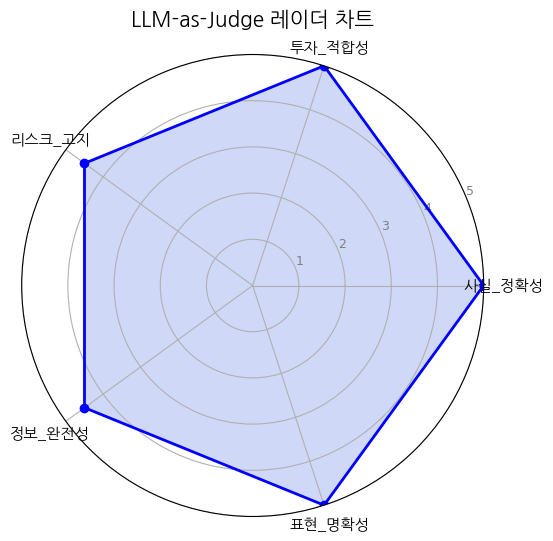

In [110]:
import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 구글 폰트(Google Fonts)의 안정적인 공식 주소로 변경!
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
font_path = "NanumGothic.ttf"
urllib.request.urlretrieve(font_url, font_path)

# 2. 다운로드한 파일로 폰트 객체 강제 생성
font_prop = fm.FontProperties(fname=font_path)

# 실습 11 기본 데이터 준비
labels = ["사실_정확성", "투자_적합성", "리스크_고지", "정보_완전성", "표현_명확성"]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# 3. 데이터 추출 및 차트 그리기
valid_scores = [j["scores"] for j in all_judgments if "error" not in j]

if valid_scores:
    df_scores = pd.DataFrame(valid_scores)
    mean_scores = df_scores.mean()

    values = [
        mean_scores.get("정확성", 0),
        mean_scores.get("관련성", 0),
        mean_scores.get("안전성", 0),
        mean_scores.get("완전성", 0),
        mean_scores.get("명확성", 0)
    ]
    values += values[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    ax.fill(angles, values, alpha=0.25, color='royalblue')
    ax.plot(angles, values, 'o-', linewidth=2, color='blue')

    ax.set_xticks(angles[:-1])

    # ⭐ 폰트 객체(font_prop)를 라벨에 주입 ⭐
    xtick_labels = ax.set_xticklabels(labels)
    for t in xtick_labels:
        t.set_fontproperties(font_prop)
        t.set_fontsize(11)

    ax.set_ylim(0, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_yticklabels(['1', '2', '3', '4', '5'], color='grey', size=9)

    # ⭐ 타이틀에도 폰트 객체 주입 ⭐
    title_obj = ax.set_title('LLM-as-Judge 레이더 차트', pad=20)
    title_obj.set_fontproperties(font_prop)
    title_obj.set_fontsize(15)

    plt.show()

else:
    print("유효한 평가 결과가 없어 차트를 그릴 수 없습니다.")

---
### 종합 평가 파이프라인

In [111]:
# 종합 평가 파이프라인
class ETFEvaluationPipeline:
    def __init__(self, thresholds=None):
        self.thresholds = thresholds or {"ROUGE-1": 0.3, "BERTScore": 0.7, "LLM_Judge": 15}
        self.results = []

    def evaluate_single(self, query, answer, reference, context):
        bleu4 = compute_bleu(reference, answer, max_n=4)
        r1 = rouge_n(reference, answer, 1)["f1"]
        r2 = rouge_n(reference, answer, 2)["f1"]
        rl = rouge_l(reference, answer)["f1"]
        bs = simple_bertscore(reference, answer)
        judge = llm_judge(query, answer, context)
        judge_total = judge.get("총점", 0)

        gate = {
            "ROUGE-1": r1 >= self.thresholds["ROUGE-1"],
            "BERTScore": bs >= self.thresholds["BERTScore"],
            "LLM_Judge": judge_total >= self.thresholds["LLM_Judge"],
        }
        if not gate.get("BERTScore"):
            status = "🔴 FAIL"
        elif not all(gate.values()):
            status = "🟡 WARN"
        else:
            status = "🟢 PASS"

        result = {"query": query[:30], "BLEU-4": bleu4, "ROUGE-1": r1, "ROUGE-2": r2,
                  "ROUGE-L": rl, "BERTScore": bs, "LLM_Judge": judge_total, "status": status}
        self.results.append(result)
        return result

    def evaluate_batch(self, eval_data, answer_fn):
        for item in eval_data:
            answer = answer_fn(item["query"])
            context = "\n".join([c for _, _, c in hybrid_search(item["query"], k=3)])
            self.evaluate_single(item["query"], answer, item["reference"], context)
        return self

    def summary(self):
        df = pd.DataFrame(self.results)
        print("=== 종합 평가 결과 ===")
        print(df[["query", "BLEU-4", "ROUGE-1", "BERTScore", "LLM_Judge", "status"]].to_string(index=False))
        print(f"\n🟢 PASS: {sum(1 for r in self.results if '🟢' in r['status'])}")
        print(f"🟡 WARN: {sum(1 for r in self.results if '🟡' in r['status'])}")
        print(f"🔴 FAIL: {sum(1 for r in self.results if '🔴' in r['status'])}")
        return df

print("✅ ETFEvaluationPipeline 준비 완료")

✅ ETFEvaluationPipeline 준비 완료


### 실습 12: 통합 평가 파이프라인 실행

`ETFEvaluationPipeline`으로 전체 평가를 실행하고 CSV로 저장하세요.

- `evaluate_batch()` → `summary()` → `.to_csv()`

In [ ]:
# 실습 12
pipeline = ETFEvaluationPipeline()
# ---- 여기에 코드 작성 ----

---
### Gradio 평가 대시보드

In [ ]:
# Gradio 기본 대시보드
import gradio as gr

def evaluate_query(query, reference=""):
    initial = hybrid_search(query, k=7)
    reranked = llm_rerank(query, initial, top_k=3)
    filtered = score_filter(reranked, method="dynamic")

    context = "\n".join([f"[{did}] {c}" for did, _, c in filtered])
    answer = ChatOpenAI(model=MODEL, temperature=0).invoke([
        SystemMessage(content="ETF 전문가입니다. 검색된 문서만을 근거로 답변하세요."),
        HumanMessage(content=f"참고 문서:\n{context}\n\n질문: {query}")
    ]).content

    search_info = "📋 검색 결과:\n" + "\n".join([f"  [{did}] score={score}" for did, score, _ in filtered])

    metrics_info = ""
    if reference.strip():
        b4 = compute_bleu(reference, answer, max_n=4)
        r1 = rouge_n(reference, answer, 1)["f1"]
        rl = rouge_l(reference, answer)["f1"]
        bs = simple_bertscore(reference, answer)
        metrics_info = f"BLEU-4: {b4:.4f} | ROUGE-1: {r1:.4f} | ROUGE-L: {rl:.4f} | BERTScore: {bs:.4f}"
    else:
        metrics_info = "참조 답변을 입력하면 자동 평가가 표시됩니다."

    judge = llm_judge(query, answer, context)
    judge_info = f"총점: {judge.get('총점', 'N/A')}/25 | 피드백: {judge.get('피드백', 'N/A')[:200]}"

    return answer, search_info, metrics_info, judge_info

print("✅ evaluate_query 준비 완료")

### 실습 13: 평가 대시보드 확장

기존 `evaluate_query`에 Criteria 평가와 품질 게이트를 추가하세요.

- `criteria_evaluation()` 결과 추가
- 출력에 Criteria 평가 Textbox 추가
- 품질 게이트: BERTScore >= 0.7 and LLM 총점 >= 15 → PASS

In [ ]:
# 실습 13
# ---- 여기에 코드 작성 ----
# 1) evaluate_query_extended 함수: criteria_evaluation 결과 추가
# 2) gr.Interface 에 Criteria 평가 출력 추가
# 3) 품질 게이트 판정

---
### 체크포인트 저장

In [ ]:
# Weekend 2 체크포인트 저장
os.makedirs("project2_data/checkpoints", exist_ok=True)

weekend2_results = {
    "timestamp": datetime.now().isoformat(),
    "evaluation_metrics": ["BLEU", "ROUGE", "BERTScore", "LLM-as-Judge", "Criteria"],
    "pipeline_config": {"search_k": 7, "rerank_k": 3, "filter_method": "dynamic", "model": MODEL},
    "quality_gate_thresholds": {"ROUGE-1": 0.3, "BERTScore": 0.7, "LLM_Judge": 15},
}
with open("project2_data/checkpoints/weekend2_results.json", "w") as f:
    json.dump(weekend2_results, f, ensure_ascii=False, indent=2)

with open("project2_data/checkpoints/weekend2_answers.json", "w") as f:
    json.dump(answers, f, ensure_ascii=False, indent=2)

weekend2_state = {
    "weekend": 2, "completed": True,
    "achievements": [
        "LLM 리랭킹 파이프라인", "스코어 필터링", "프롬프트 최적화",
        "BLEU/ROUGE/BERTScore 평가", "한국어 토큰화",
        "LLM-as-Judge", "Criteria 평가", "종합 파이프라인 + 품질 게이트",
    ]
}
with open("project2_data/checkpoints/weekend2_state.json", "w") as f:
    json.dump(weekend2_state, f, ensure_ascii=False, indent=2)

print("✅ Weekend 2 체크포인트 저장 완료")

### 실습 14: 통합 리포트 + 체크리스트

Weekend 1+2 통합 리포트를 JSON으로 저장하고 필수 파일 체크리스트를 확인하세요.

- `report` 딕셔너리에 weekend1, weekend2 정보 통합
- 벡터 스토어, ETF 문서, 결과 파일 존재 여부 체크리스트 출력

In [ ]:
# 실습 14
report = {
    "weekend1": {"methods": ["FAISS", "BM25", "Hybrid"], "best": "Hybrid"},
    "weekend2": weekend2_state,
}
# ---- 여기에 코드 작성 ----